In [11]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from IPython.display import display
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

In [12]:
current_directory = Path.cwd()

if (current_directory / "data" / "raw").exists():
    PROJECT_ROOT = current_directory
elif (current_directory.parent / "data" / "raw").exists():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError(
        "Open Jupyter from the project folder."
    )

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "diabetes.csv"

PROCESSED_DIRECTORY = PROJECT_ROOT / "data" / "processed"
FIGURES_DIRECTORY = PROJECT_ROOT / "reports" / "figures"
METRICS_DIRECTORY = PROJECT_ROOT / "reports" / "metrics"

for directory in [
    PROCESSED_DIRECTORY,
    FIGURES_DIRECTORY,
    METRICS_DIRECTORY,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project: /home/bsar/Desktop/diabetes-profile-ai
Dataset: /home/bsar/Desktop/diabetes-profile-ai/data/raw/diabetes.csv
Dataset exists: True


In [13]:
df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip()


if df.columns.duplicated().any():
    raise ValueError("the dataset has fuplicate column names ")

print("Rows:" , df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Rows: 768
Columns: 9


,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,2,8,183,64,0,0,23.3,0.672,32
3,3,1,89,66,23,94,28.1,0.167,21
4,4,0,137,40,35,168,43.1,2.288,33


In [14]:
print("columns names:")
print(df.columns.tolist())

print("\n data types and non-missing counts:")
df.info()

columns names:
['Unnamed: 0', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

 data types and non-missing counts:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             768 non-null    int64  
 4   SkinThickness             768 non-null    int64  
 5   Insulin                   768 non-null    int64  
 6   BMI                       768 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [15]:
FEATURES = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

missing_columns = [
    column 
    for column in FEATURES
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"missing expected columns: {missing_columns}."
        f"available columns:{df.columns.tolist()}"
    )


extra_columns = [
    column
    for column in df.columns
    if column not in FEATURES
]

print("Selected features:" ,FEATURES)
print("Other columns: " , extra_columns)

Selected features: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Other columns:  ['Unnamed: 0', 'Pregnancies']


In [16]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pecent": df.isna().sum() * 100
})

display(
    missing_summary.sort_values(
        "missing_count",
        ascending=False
    )
)

duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)

if duplicate_count > 0 :
    display(
        df.loc[df.duplicated(keep=False)].head(10)
    )

,missing_count,missing_pecent
Unnamed: 0,0,0
Pregnancies,0,0
Glucose,0,0
BloodPressure,0,0
SkinThickness,0,0
Insulin,0,0
BMI,0,0
DiabetesPedigreeFunction,0,0
Age,0,0


Exact duplicate rows: 0


In [17]:
data = df.drop_duplicates().copy()


data.index.name = "source_row" 

print("original rows:", len(df))
print("rows after removing exact duplicates:", len(data))

original rows: 768
rows after removing exact duplicates: 768


In [18]:
train_data, test_data = train_test_split(
    data,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_data = train_data.copy()
test_data= test_data.copy()

print("Training rows:", len(train_data))
print("test rows:", len(test_data))

assert set(train_data.index).isdisjoint(test_data.index)

Training rows: 614
test rows: 154


In [19]:
X_train = train_data[FEATURES].copy()

numeric_train = X_train.apply(
    pd.to_numeric,
    errors="coerce",
)

# Find values that were present but could not be read as numbers.
invalid_values = X_train.notna() & numeric_train.isna()

display(
    invalid_values.sum().rename("invalid_numeric_count")
)

if invalid_values.any().any():
    display(
        X_train.loc[invalid_values.any(axis=1)].head(10)
    )

    raise ValueError(
        "Some feature values are not numeric. "
        "Inspect them before continuing."
    )

if np.isinf(numeric_train.to_numpy()).any():
    raise ValueError(
        "Infinite values found. Inspect them before continuing."
    )

X_train = numeric_train

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Name: invalid_numeric_count, dtype: int64

In [20]:
quality_report = pd.DataFrame({
    "missing_count": X_train.isna().sum(),
    "missing_percent": X_train.isna().mean() * 100,
    "zero_count": X_train.eq(0).sum(),
    "negative_count": X_train.lt(0).sum(),
    "unique_values": X_train.nunique(),
})

display(quality_report.round(2))

quality_report.to_csv(
    METRICS_DIRECTORY / "training_data_quality.csv",
    index_label="feature",
)

,missing_count,missing_percent,zero_count,negative_count,unique_values
Glucose,0,0.0,5,0,133
BloodPressure,0,0.0,24,0,44
SkinThickness,0,0.0,176,0,47
Insulin,0,0.0,290,0,167
BMI,0,0.0,7,0,225
DiabetesPedigreeFunction,0,0.0,0,0,443
Age,0,0.0,0,0,52


In [21]:
# Descriptive statistics

statistics = X_train.describe().T

display(statistics.round(2))

statistics.to_csv(
    METRICS_DIRECTORY / "training_data_quality.csv",
    index_label="feature",
)

,count,mean,std,min,25%,50%,75%,max
Glucose,614.0,120.86,32.04,0.00,100.00,117.00,139.00,199.00
BloodPressure,614.0,69.42,18.51,0.00,64.00,72.00,80.00,122.00
SkinThickness,614.0,20.40,15.43,0.00,0.00,23.00,32.00,63.00
Insulin,614.0,81.44,116.23,0.00,0.00,42.50,129.75,846.00
BMI,614.0,31.98,7.74,0.00,27.10,32.00,36.38,67.10
DiabetesPedigreeFunction,614.0,0.47,0.34,0.08,0.24,0.37,0.61,2.42
Age,614.0,32.91,11.50,21.00,24.00,29.00,40.00,81.00


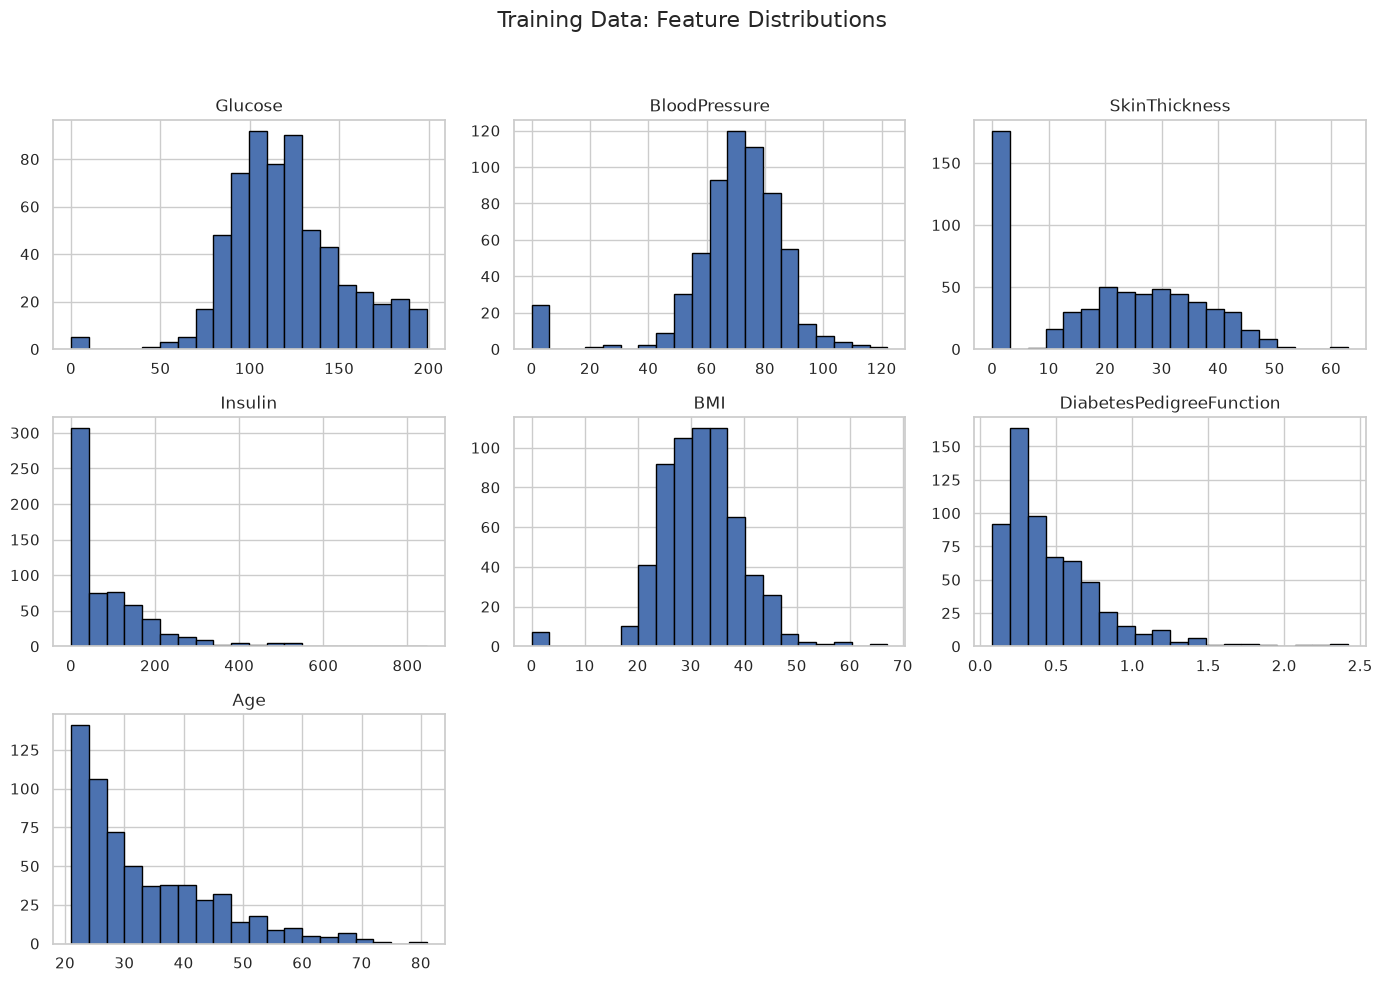

In [22]:
X_train.hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black",
)

plt.suptitle(
    "Training Data: Feature Distributions",
    fontsize=16,
)

plt.tight_layout(rect=(0, 0, 1, 0.95))

plt.savefig(
    FIGURES_DIRECTORY / "feature_distributions.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

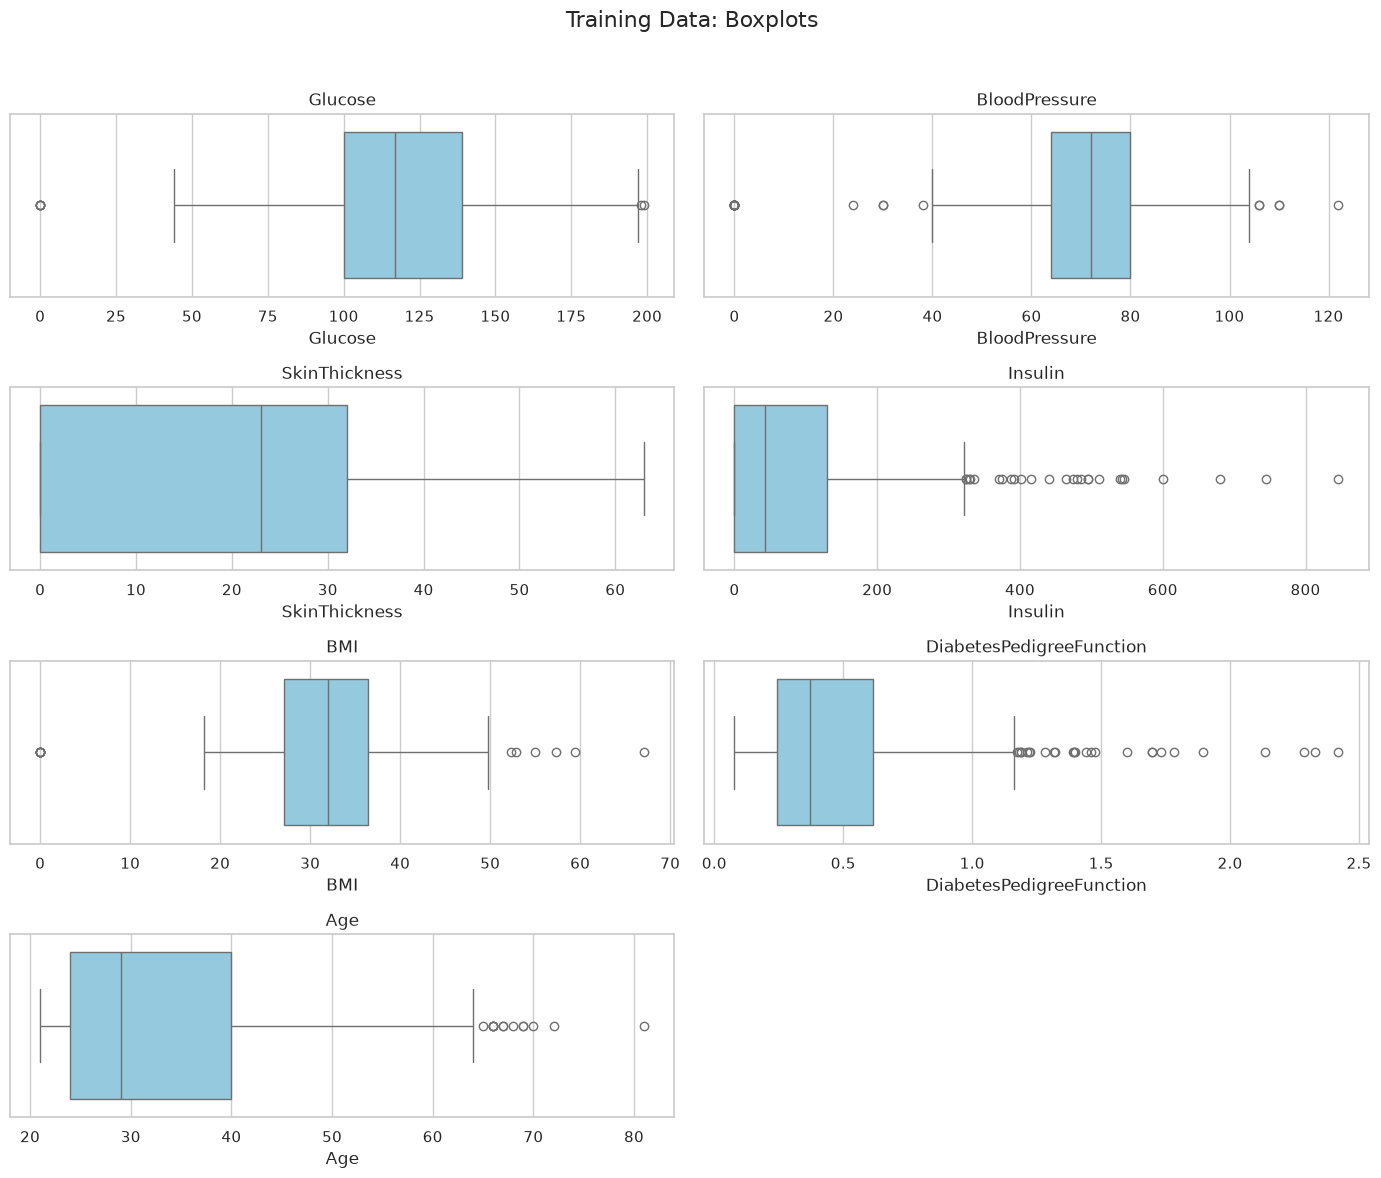

In [23]:
# Each feature gets its own scale

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 12),
)

axes = axes.flatten()

for axis, feature in zip(axes, FEATURES):
    sns.boxplot(
        x=X_train[feature],
        ax=axis,
        color="skyblue",
    )

    axis.set_title(feature)

for axis in axes[len(FEATURES):]:
    axis.set_visible(False)

fig.suptitle(
    "Training Data: Boxplots",
    fontsize=16,
)

fig.tight_layout(rect=(0, 0, 1, 0.96))

fig.savefig(
    FIGURES_DIRECTORY / "feature_boxplots.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [24]:
train_data.to_csv(
    PROCESSED_DIRECTORY / "train_raw.csv",
    index=True
)

test_data.to_csv(
    PROCESSED_DIRECTORY / "test_raw.csv",
    index=True
)

dataset_checksum = hashlib.sha256(
    DATA_PATH.read_bytes()
).hexdigest()


split_metadata = {
    "dataset_filename": DATA_PATH.name,
    "dataset_sha256": dataset_checksum,
    "random_state": RANDOM_STATE,
    "test_size": 0.20,
    "original_rows": len(df),
    "exact_duplicates_removed": int(duplicate_count),
    "training_rows": len(train_data),
    "test_rows": len(test_data),
    "features": FEATURES,
    "training_source_rows": train_data.index.tolist(),
    "test_source_rows": test_data.index.tolist(),
}

with open(
    PROCESSED_DIRECTORY / "split_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(split_metadata, file, indent=2)


print("Trainig data , test data, and split metadata saved.")

Trainig data , test data, and split metadata saved.
